## Exploratory Data Analysis

## Nepali Text and Tokenizer Fertility Analysis

**Student:** Udhav Kharel  
**Project:** Nepali NLP Tokenizer Analysis  
**Dataset:** OSCAR Corpus Nepali  
**Data Type:** Text / NLP

### Research Question

How do mBERT, XLM-R, and a custom BPE tokenizer differ in
tokenization fertility for Nepali text, and how does fertility
change with word length and morphological inflection?

### Objective

This project performs exploratory data analysis on a Nepali text corpus
and compares three subword tokenizers. The analysis examines corpus
quality, text length, vocabulary, linguistic noise, tokenizer fertility,
word length, and root versus inflected Nepali word forms.

## Importing the database

In [1]:
import kagglehub

path = kagglehub.dataset_download("hsebarp/oscar-corpus-nepali")

print("Path to dataset files:", path)

Path to dataset files: /home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1


##

## Finding and printing the absolute or relative file paths of every single file inside a folder

In [2]:
import sys
print(sys.executable)

/home/udhavkharel/Desktop/Nepali_tokenizer/venv/bin/python


In [3]:
!pip install kagglehub


In [4]:
import kagglehub

path = kagglehub.dataset_download("hsebarp/oscar-corpus-nepali")

print("Dataset downloaded to:", path)

Dataset downloaded to: /home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1


In [5]:
import os

print("Files in dataset directory:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Files in dataset directory:
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1/ne.txt
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1/ne_dedup.txt


## Removing the Duplicate file

In [6]:
import os

ne_dedup_path = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file == "ne_dedup.txt":
            ne_dedup_path = os.path.join(root, file)

print("Deduplicated file:")
print(ne_dedup_path)

Deduplicated file:
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1/ne_dedup.txt


## Installation of Required Packages

In [7]:
!pip install -q kagglehub transformers tokenizers pandas numpy matplotlib seaborn regex

## Importing necessary Libraries

In [8]:
import os
import re
import unicodedata
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import kagglehub

from transformers import AutoTokenizer

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFKC

## Setting up Reproducibility

In [9]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")

## Downloading the Dataset

In [10]:
path = kagglehub.dataset_download(
    "hsebarp/oscar-corpus-nepali"
)

print("Dataset path:")
print(path)

Dataset path:
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1


## Identifying the Files

In [11]:
dataset_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        full_path = os.path.join(root, file)
        dataset_files.append(full_path)

print("Dataset files:")

for file in dataset_files:
    print(file)

Dataset files:
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1/ne.txt
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1/ne_dedup.txt


## Select ne_dedup.txt

In [12]:
ne_dedup_path = None

for file in dataset_files:
    if os.path.basename(file) == "ne_dedup.txt":
        ne_dedup_path = file
        break

if ne_dedup_path is None:
    raise FileNotFoundError(
        "ne_dedup.txt was not found."
    )

print("Using:")
print(ne_dedup_path)

Using:
/home/udhavkharel/.cache/kagglehub/datasets/hsebarp/oscar-corpus-nepali/versions/1/ne_dedup.txt


## 1. Dataset Card

### Dataset Name

OSCAR Corpus Nepali

### Source

Kaggle – OSCAR Corpus Nepali

### Kaggle Dataset

https://www.kaggle.com/hsebarp/oscar-corpus-nepali

### Files

The dataset contains:

- `ne.txt`
- `ne_dedup.txt`

The original `ne.txt` file is approximately 1.86 GB uncompressed,
while `ne_dedup.txt` is approximately 1.2 GB uncompressed.

### File Used

This project uses `ne_dedup.txt` because the dataset description
states that duplicate lines have already been removed.

### Language

Nepali

### Data Type

Text corpus

### Collection

The corpus is derived from the OSCAR corpus and consists of Nepali
text collected from web sources. The Kaggle description states that
the data is shuffled at line level and does not provide metadata.

### Purpose

The corpus is used here to investigate Nepali text characteristics
and compare subword tokenizer fertility.

### Limitations

The corpus is web-derived and may contain:

- spelling variation
- mixed-language text
- URLs
- numbers
- duplicated or near-duplicated content
- web artifacts
- inconsistent Unicode
- uneven topic representation

The corpus also does not provide detailed information about individual
authors or demographic representation.

## Number of samples

In [13]:
def count_lines(file_path):
    count = 0

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as f:
        for _ in f:
            count += 1

    return count


total_lines = count_lines(ne_dedup_path)

print("Total samples/lines:", total_lines)

Total samples/lines: 1490594


## Determining the File size

In [14]:
file_size_bytes = os.path.getsize(ne_dedup_path)

file_size_gb = file_size_bytes / (1024 ** 3)

print(
    f"File size: {file_size_gb:.2f} GB"
)

File size: 1.15 GB


## Loading the Managable Sample

In [15]:
SAMPLE_SIZE = 100_000

## Reading the Samples

In [16]:
rng = random.Random(RANDOM_SEED)

sample_lines = []

with open(
    ne_dedup_path,
    "r",
    encoding="utf-8",
    errors="replace"
) as f:

    for line_number, line in enumerate(f):

        line = line.strip()

        if line:
            sample_lines.append(line)

        if len(sample_lines) >= SAMPLE_SIZE:
            break

print("Loaded samples:", len(sample_lines))


# This takes the first 100000 non empty lines

Loaded samples: 100000


## Sampling method

In [17]:
def reservoir_sample(file_path, k, seed=42):
    rng = random.Random(seed)
    reservoir = []

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="replace"
    ) as f:

        for i, line in enumerate(f):

            line = line.strip()

            if not line:
                continue

            if len(reservoir) < k:
                reservoir.append(line)
            else:
                j = rng.randint(0, i)

                if j < k:
                    reservoir[j] = line

    return reservoir


sample_lines = reservoir_sample(
    ne_dedup_path,
    SAMPLE_SIZE,
    RANDOM_SEED
)

print("Sample size:", len(sample_lines))


Sample size: 100000


## Creating a Dataframe

In [18]:
df = pd.DataFrame({
    "text": sample_lines
})

print("Shape:", df.shape)

Shape: (100000, 1)


## Printing random Samples

In [19]:
display(
    df.sample(
        5,
        random_state=RANDOM_SEED
    )
)

,text
75721,काठमाडौं – नयाँ शक्ति पार्टी र संघीय समाजवादी ...
80184,मखमली फूलको आफ्नै फरक महत्व बोकेको हुन्छ । हरे...
19864,राष्ट्रियसभा निर्वाचनमा यतिबेला कसैको चर्चा छ ...
76699,अग्रज श्रष्टाका सुन्दर रचनाका साथमा उद्गार सुन...
92991,"त्यसैगरी २५ लाखसम्म विगो भएको घरबहाल, अरुको जग..."


## Printing the shape and datatpyes

In [20]:
print("Shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nDataFrame information:")
df.info()

Shape:
(100000, 1)

Data types:
text    str
dtype: object

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    100000 non-null  str  
dtypes: str(1)
memory usage: 781.4 KB


## Finding Missing Datas

In [21]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
text    0
dtype: int64


## Sorting Missing Data

In [22]:
empty_count = (
    df["text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty text records:", empty_count)

Empty text records: 0


## Verifying for any Duplicate data

In [23]:
duplicate_count = df["text"].duplicated().sum()

print("Duplicate records:", duplicate_count)

duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(
    f"Duplicate percentage: {duplicate_percentage:.2f}%"
)

Duplicate records: 2
Duplicate percentage: 0.00%


### Duplicate Handling Decision

The project uses `ne_dedup.txt`, which is already described by the
dataset provider as having duplicate lines removed. Nevertheless,
duplicates are checked again on the sampled data as a data-quality
verification step.

If duplicates are found in the sample, exact duplicate records will
be removed before vocabulary and tokenizer analysis so that repeated
text does not disproportionately affect the results.

## Unicode Cleaning

In [24]:
def normalize_text(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize(
        "NFKC",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [25]:
df["clean_text"] = (
    df["text"]
    .apply(normalize_text)
)

display(df.head())

,text,clean_text
0,सम्झौताअनुसार सो आयोजनाबाट उत्पादित विद्युत् ह...,सम्झौताअनुसार सो आयोजनाबाट उत्पादित विद्युत् ह...
1,भन्ने आरोप) बिबादलाई पनि जोडेर हेर्न सकिन्छ। स...,भन्ने आरोप) बिबादलाई पनि जोडेर हेर्न सकिन्छ। स...
2,सक्षार सप्तरी अभियानमा सप्तरीबासी सम्पूर्ण सरो...,सक्षार सप्तरी अभियानमा सप्तरीबासी सम्पूर्ण सरो...
3,काठमाडौं। नेपाली कांग्रेसभित्र १३औं महाधिवेशनप...,काठमाडौं। नेपाली कांग्रेसभित्र १३औं महाधिवेशनप...
4,सेप्टेम्बर १ देखि १२ सम्मको समयमा विस्थापितको ...,सेप्टेम्बर १ देखि १२ सम्मको समयमा विस्थापितको ...


## Removing the Empty Records

In [26]:
before_cleaning = len(df)

df = df[
    df["clean_text"].str.len() > 0
].copy()

df = df.drop_duplicates(
    subset=["clean_text"]
).reset_index(drop=True)

after_cleaning = len(df)

print("Before cleaning:", before_cleaning)
print("After cleaning:", after_cleaning)
print(
    "Records removed:",
    before_cleaning - after_cleaning
)

Before cleaning: 100000
After cleaning: 99994
Records removed: 6


## Cleaning Strategy

The cleaning process is deliberately conservative.

I normalize Unicode, normalize whitespace, remove empty records, and
remove exact duplicates. I do not remove punctuation, English words,
numbers, URLs, or emojis before the tokenizer analysis because these
features are part of the natural noise present in web-derived text.

This allows the EDA to measure the linguistic and textual conditions
that a tokenizer may encounter in a real Nepali NLP application.

## Text length

In [27]:
# Calculating the Characters
df["char_count"] = (
    df["clean_text"]
    .str.len()
)

# Calculating the Words
df["word_count"] = (
    df["clean_text"]
    .str.split()
    .str.len()
)
# Calculating the Statistics
display(
    df[
        ["char_count", "word_count"]
    ].describe()
)


,char_count,word_count
count,99994.000000,99994.000000
mean,310.357601,48.252575
std,312.904700,49.036927
min,98.000000,1.000000
25%,171.000000,26.000000
50%,247.000000,38.000000
75%,367.000000,57.000000
max,53890.000000,8400.000000


## Plot character distribution

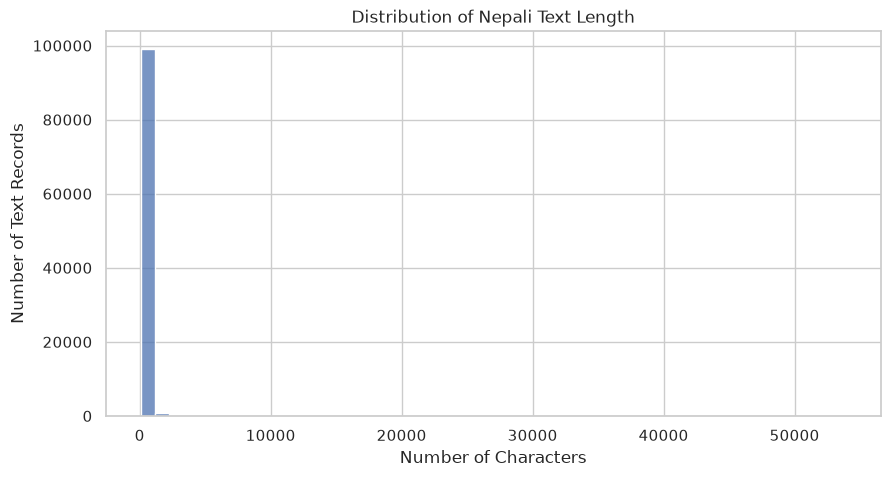

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["char_count"],
    bins=50
)

plt.title(
    "Distribution of Nepali Text Length"
)

plt.xlabel(
    "Number of Characters"
)

plt.ylabel(
    "Number of Text Records"
)

plt.show()

## Plot word-count distribution

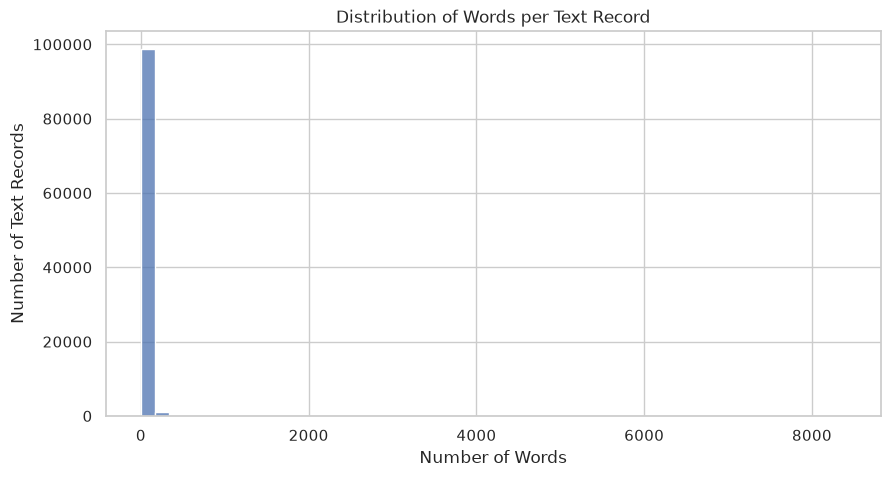

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["word_count"],
    bins=50
)

plt.title(
    "Distribution of Words per Text Record"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Number of Text Records"
)

plt.show()

## Vocabulary Size

In [30]:
all_words = []

for text in df["clean_text"]:
    all_words.extend(
        text.split()
    )

word_counter = Counter(all_words)

print(
    "Total word tokens:",
    len(all_words)
)

print(
    "Unique word types:",
    len(word_counter)
)

Total word tokens: 4824968
Unique word types: 396322


## Top 30 words

In [31]:
top_30_words = pd.DataFrame(
    word_counter.most_common(30),
    columns=[
        "word",
        "frequency"
    ]
)

display(top_30_words)

,word,frequency
0,।,221551
1,र,85891
2,छ,63768
3,पनि,45778
4,भएको,29930
5,लागि,23890
6,गरेको,22768
7,छन्,21715
8,गर्न,20718
9,हो,20289


## Top 30 Plot

/home/udhavkharel/Desktop/Nepali_tokenizer/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2404 (\N{DEVANAGARI DANDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/udhavkharel/Desktop/Nepali_tokenizer/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/udhavkharel/Desktop/Nepali_tokenizer/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2331 (\N{DEVANAGARI LETTER CHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/udhavkharel/Desktop/Nepali_tokenizer/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/udhavkharel/Desktop/Nepali_tokenizer/venv/lib/python3

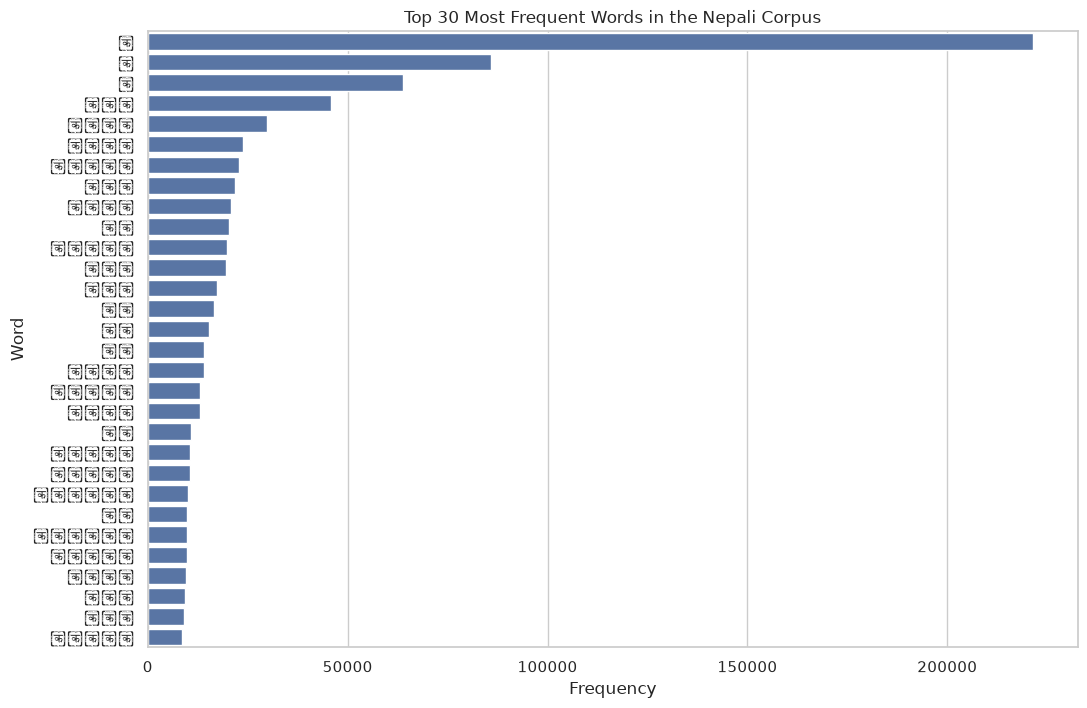

In [32]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_30_words,
    x="frequency",
    y="word"
)

plt.title(
    "Top 30 Most Frequent Words in the Nepali Corpus"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()


## Noise Audit

In [33]:
url_pattern = re.compile(
    r"https?://\S+|www\.\S+"
)

df["has_url"] = (
    df["clean_text"]
    .apply(
        lambda x: bool(url_pattern.search(x))
    )
)

print(
    "Records containing URLs:",
    df["has_url"].sum()
)

Records containing URLs: 133


## English / Latin script

In [34]:
latin_pattern = re.compile(
    r"[A-Za-z]"
)

df["has_latin"] = (
    df["clean_text"]
    .apply(
        lambda x: bool(latin_pattern.search(x))
    )
)

print(
    "Records containing Latin characters:",
    df["has_latin"].sum()
)

Records containing Latin characters: 4382


## Devanagari

In [35]:
devanagari_pattern = re.compile(
    r"[\u0900-\u097F]"
)

df["has_devanagari"] = (
    df["clean_text"]
    .apply(
        lambda x: bool(
            devanagari_pattern.search(x)
        )
    )
)

print(
    "Records containing Devanagari:",
    df["has_devanagari"].sum()
)

Records containing Devanagari: 99779


## Digits

In [36]:
digit_pattern = re.compile(
    r"\d"
)

df["has_digits"] = (
    df["clean_text"]
    .apply(
        lambda x: bool(
            digit_pattern.search(x)
        )
    )
)

print(
    "Records containing digits:",
    df["has_digits"].sum()
)

Records containing digits: 45732


## Mentions

In [37]:
mention_pattern = re.compile(
    r"@\w+"
)

df["has_mentions"] = (
    df["clean_text"]
    .apply(
        lambda x: bool(
            mention_pattern.search(x)
        )
    )
)

print(
    "Records containing mentions:",
    df["has_mentions"].sum()
)

Records containing mentions: 43


## Emojis

In [38]:
emoji_pattern = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "]"
)

df["has_emoji"] = (
    df["clean_text"]
    .apply(
        lambda x: bool(
            emoji_pattern.search(x)
        )
    )
)

print(
    "Records containing emojis:",
    df["has_emoji"].sum()
)

Records containing emojis: 12


## Noisy Summary Table

In [39]:
noise_summary = pd.DataFrame({
    "Feature": [
        "URLs",
        "Latin/English characters",
        "Devanagari",
        "Digits",
        "Mentions",
        "Emojis"
    ],
    "Number of records": [
        df["has_url"].sum(),
        df["has_latin"].sum(),
        df["has_devanagari"].sum(),
        df["has_digits"].sum(),
        df["has_mentions"].sum(),
        df["has_emoji"].sum()
    ]
})

noise_summary["Percentage"] = (
    noise_summary["Number of records"]
    / len(df)
    * 100
)

display(noise_summary)

,Feature,Number of records,Percentage
0,URLs,133,0.133008
1,Latin/English characters,4382,4.382263
2,Devanagari,99779,99.784987
3,Digits,45732,45.734744
4,Mentions,43,0.043003
5,Emojis,12,0.012001


## Noise Plot

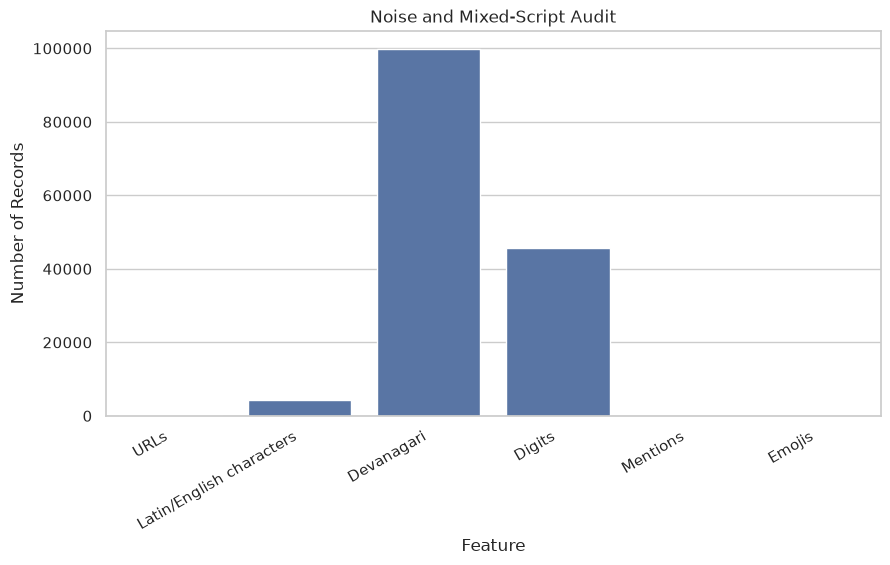

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=noise_summary,
    x="Feature",
    y="Number of records"
)

plt.title(
    "Noise and Mixed-Script Audit"
)

plt.xlabel("Feature")
plt.ylabel("Number of Records")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

### Romanized Nepali

The dataset does not provide a direct annotation identifying Romanized
Nepali. Therefore, Latin-script detection is used only as an indicator
of possible Romanized or mixed-script content. It cannot distinguish
Romanized Nepali from English or other Latin-script text perfectly.

## Target/Class Distribution

This project is an exploratory tokenizer study rather than a supervised
classification task. Therefore, the corpus does not contain a target
class variable.

A conventional class-distribution plot is therefore not applicable.

Instead, the analysis uses word-frequency distributions, text-length
distributions, noise distributions, tokenizer fertility, and
root-versus-inflected word comparisons as the main EDA targets.

Because there is no classification target, class imbalance is not
directly applicable to this project.

## Train / Validation / Test Split

This project does not train a conventional supervised classification
model, so stratified class splitting is not appropriate.

The corpus is divided into:

- 80% training data
- 10% validation data
- 10% test data

The training set is used to train the custom BPE tokenizer.

The validation set is reserved for development and vocabulary-size
decisions.

The test set is kept separate for the final fertility analysis.

This separation prevents the custom tokenizer from being evaluated only
on text that was directly used to learn its vocabulary.

## Creating Split

In [41]:
df = df.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

n = len(df)

train_end = int(n * 0.80)
validation_end = int(n * 0.90)

train_df = df.iloc[
    :train_end
].copy()

validation_df = df.iloc[
    train_end:validation_end
].copy()

test_df = df.iloc[
    validation_end:
].copy()

print(
    "Training:",
    len(train_df)
)

print(
    "Validation:",
    len(validation_df)
)

print(
    "Test:",
    len(test_df)
)

Training: 79995
Validation: 9999
Test: 10000


# mBERT, XLM-R, BPE

## Loading mBERT tokenizer

In [42]:
mbert_tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-multilingual-cased"
)

print(
    "mBERT tokenizer loaded."
)

mBERT tokenizer loaded.


## Loading XLM-R

In [43]:
xlmr_tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)

print(
    "XLM-R tokenizer loaded."
)

XLM-R tokenizer loaded.


## Testing them

In [44]:
test_words = [
    "नेपाल",
    "विद्यालय",
    "विद्यार्थी",
    "घरमा",
    "नेपालको"
]

for word in test_words:

    print("\nWord:", word)

    print(
        "mBERT:",
        mbert_tokenizer.tokenize(word)
    )

    print(
        "XLM-R:",
        xlmr_tokenizer.tokenize(word)
    )


Word: नेपाल
mBERT: ['नेपाल']
XLM-R: ['▁नेपाल']

Word: विद्यालय
mBERT: ['वि', '##द्यालय']
XLM-R: ['▁विद्यालय']

Word: विद्यार्थी
mBERT: ['वि', '##द्य', '##ार', '##्थ', '##ी']
XLM-R: ['▁विद्यार्थी']

Word: घरमा
mBERT: ['घर', '##मा']
XLM-R: ['▁घरमा']

Word: नेपालको
mBERT: ['नेपालको']
XLM-R: ['▁नेपालको']


## Train BPE tokenize

In [45]:
custom_bpe = Tokenizer(
    BPE(
        unk_token="[UNK]"
    )
)

custom_bpe.normalizer = NFKC()

custom_bpe.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=16_000,
    min_frequency=2,
    special_tokens=[
        "[UNK]",
        "[PAD]",
        "[CLS]",
        "[SEP]",
        "[MASK]"
    ]
)

In [46]:
training_texts = (
    train_df["clean_text"]
    .tolist()
)

### Training

In [47]:
custom_bpe.train_from_iterator(
    training_texts,
    trainer=trainer,
    length=len(training_texts)
)

print(
    "Custom BPE tokenizer trained."
)




Custom BPE tokenizer trained.


## Testing Custom BPE

In [48]:
for word in test_words:

    encoding = custom_bpe.encode(
        word
    )

    print(
        "\nWord:",
        word
    )

    print(
        "Custom BPE:",
        encoding.tokens
    )


Word: नेपाल
Custom BPE: ['नेपाल']

Word: विद्यालय
Custom BPE: ['विद्यालय']

Word: विद्यार्थी
Custom BPE: ['विद्यार्थी']

Word: घरमा
Custom BPE: ['घरमा']

Word: नेपालको
Custom BPE: ['नेपालको']


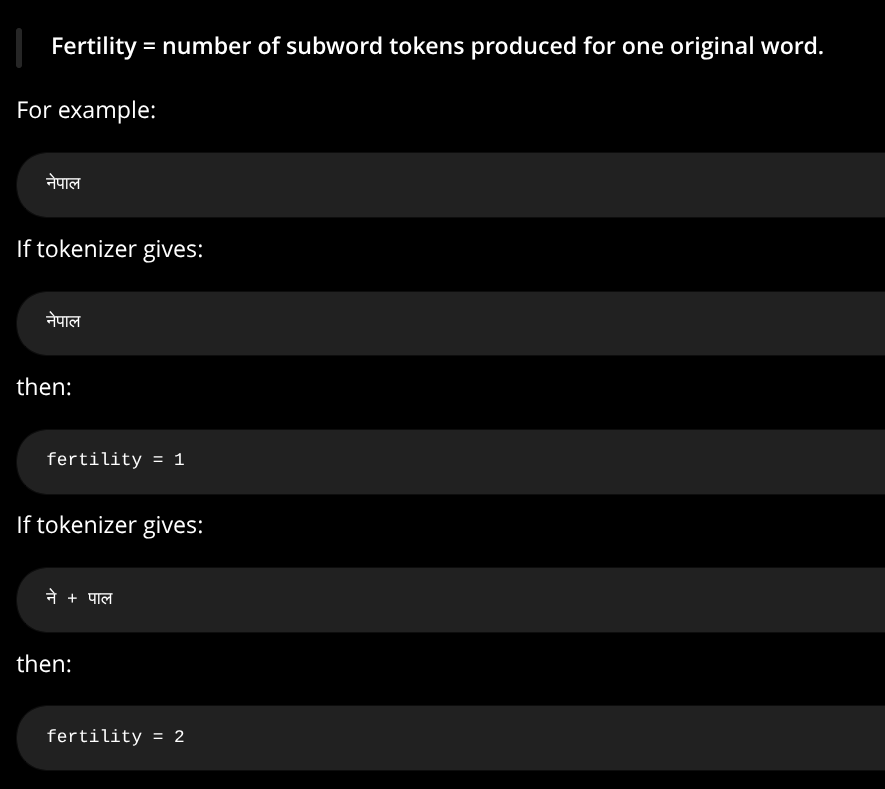

## Token-Count Function

In [49]:
def mbert_token_count(word):
    return len(
        mbert_tokenizer.tokenize(word)
    )


def xlmr_token_count(word):
    return len(
        xlmr_tokenizer.tokenize(word)
    )


def bpe_token_count(word):
    return len(
        custom_bpe.encode(word).tokens
    )

## Extract Nepali words from test set

In [50]:
word_list = []

for text in test_df["clean_text"]:

    for word in text.split():

        if re.search(
            r"[\u0900-\u097F]",
            word
        ):

            word = re.sub(
                r"^[^\u0900-\u097F]+|[^\u0900-\u097F]+$",
                "",
                word
            )

            if word:
                word_list.append(word)

print(
    "Nepali word occurrences:",
    len(word_list)
)

Nepali word occurrences: 480492


## Making Unique word dataset

In [51]:
words_df = pd.DataFrame({
    "word": word_list
})

words_df = (
    words_df
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Unique Nepali words:",
    len(words_df)
)

Unique Nepali words: 75632


## Limiting to 20,000 words

In [52]:
MAX_WORDS = 20_000

if len(words_df) > MAX_WORDS:

    words_df = (
        words_df
        .sample(
            MAX_WORDS,
            random_state=RANDOM_SEED
        )
        .reset_index(drop=True)
    )

print(
    "Words used for tokenizer analysis:",
    len(words_df)
)

Words used for tokenizer analysis: 20000


## Calculate original word length

In [53]:
words_df["word_length"] = (
    words_df["word"].str.len()
)

display(
    words_df.head()
)

,word,word_length
0,भारतीयहरुलाई,12
1,कार्यकर्ता,10
2,झर्दा,5
3,डाईमण्ड,7
4,गायक,4


## Calculate Tokens

In [54]:
words_df["mbert_tokens"] = (
    words_df["word"]
    .apply(mbert_token_count)
)

words_df["xlmr_tokens"] = (
    words_df["word"]
    .apply(xlmr_token_count)
)

words_df["bpe_tokens"] = (
    words_df["word"]
    .apply(bpe_token_count)
)

## Fertility

In [55]:
words_df["mbert_fertility"] = (
    words_df["mbert_tokens"]
)

words_df["xlmr_fertility"] = (
    words_df["xlmr_tokens"]
)

words_df["bpe_fertility"] = (
    words_df["bpe_tokens"]
)

## Inspecting Results

In [56]:
display(
    words_df[
        [
            "word",
            "word_length",
            "mbert_tokens",
            "xlmr_tokens",
            "bpe_tokens"
        ]
    ].head(20)
)

,word,word_length,mbert_tokens,xlmr_tokens,bpe_tokens
0,भारतीयहरुलाई,12,4,2,2
1,कार्यकर्ता,10,3,1,1
2,झर्दा,5,3,3,2
3,डाईमण्ड,7,4,4,2
4,गायक,4,2,1,1
5,आवश्क्ता,8,5,3,3
6,बुल्गेरियन,10,5,5,5
7,गीतमार्फत,9,5,2,2
8,भोटमाथि,7,5,2,2
9,अभिलेखलाई,9,5,3,2


## Manually Inspecting Tokenization

In [57]:
for _, row in words_df.head(10).iterrows():

    word = row["word"]

    print("=" * 60)
    print("WORD:", word)

    print(
        "mBERT:",
        mbert_tokenizer.tokenize(word)
    )

    print(
        "XLM-R:",
        xlmr_tokenizer.tokenize(word)
    )

    print(
        "Custom BPE:",
        custom_bpe.encode(word).tokens
    )

WORD: भारतीयहरुलाई
mBERT: ['भारतीय', '##हर', '##ुल', '##ाई']
XLM-R: ['▁भारतीय', 'हरुलाई']
Custom BPE: ['भारतीय', 'हरुलाई']
WORD: कार्यकर्ता
mBERT: ['कार्य', '##कर', '##्ता']
XLM-R: ['▁कार्यकर्ता']
Custom BPE: ['कार्यकर्ता']
WORD: झर्दा
mBERT: ['झ', '##र', '##्दा']
XLM-R: ['▁', 'झर', '्दा']
Custom BPE: ['झर्', 'दा']
WORD: डाईमण्ड
mBERT: ['ड', '##ाई', '##म', '##ण्ड']
XLM-R: ['▁डा', 'ई', 'म', 'ण्ड']
Custom BPE: ['डाई', 'मण्ड']
WORD: गायक
mBERT: ['ग', '##ायक']
XLM-R: ['▁गायक']
Custom BPE: ['गायक']
WORD: आवश्क्ता
mBERT: ['आ', '##व', '##श', '##्क', '##्ता']
XLM-R: ['▁आव', 'श्', 'क्ता']
Custom BPE: ['आव', 'श्', 'क्ता']
WORD: बुल्गेरियन
mBERT: ['ब', '##ुल', '##्ग', '##ेर', '##ियन']
XLM-R: ['▁', 'बुल', '्ग', 'ेर', 'ियन']
Custom BPE: ['बु', 'ल्', 'ग', 'ेर', 'ियन']
WORD: गीतमार्फत
mBERT: ['गीत', '##मा', '##र', '##्फ', '##त']
XLM-R: ['▁गीत', 'मार्फत']
Custom BPE: ['गीत', 'मार्फत']
WORD: भोटमाथि
mBERT: ['भ', '##ोट', '##मा', '##थ', '##ि']
XLM-R: ['▁भोट', 'माथि']
Custom BPE: ['भोट', 'माथि']
WORD: अभि

## Word-length group

In [58]:
def word_length_group(length):

    if length <= 3:
        return "1-3"

    elif length <= 6:
        return "4-6"

    elif length <= 9:
        return "7-9"

    elif length <= 12:
        return "10-12"

    else:
        return "13+"


words_df["length_group"] = (
    words_df["word_length"]
    .apply(word_length_group)
)

## Fertility by word length

In [59]:
fertility_by_length = (
    words_df
    .groupby("length_group")
    [
        [
            "mbert_fertility",
            "xlmr_fertility",
            "bpe_fertility"
        ]
    ]
    .mean()
    .reset_index()
)

display(
    fertility_by_length
)

,length_group,mbert_fertility,xlmr_fertility,bpe_fertility
0,1-3,2.276334,1.809850,1.559508
1,10-12,5.783409,3.515604,2.684716
2,13+,7.408742,4.341258,3.197853
3,4-6,3.435187,2.433297,1.978422
4,7-9,4.611542,3.022880,2.381213


## Conversion for Plotting

In [60]:
fertility_long = fertility_by_length.melt(
    id_vars="length_group",
    var_name="tokenizer",
    value_name="fertility"
)

fertility_long["tokenizer"] = (
    fertility_long["tokenizer"]
    .map({
        "mbert_fertility": "mBERT",
        "xlmr_fertility": "XLM-R",
        "bpe_fertility": "Custom BPE"
    })
)

display(
    fertility_long
)

,length_group,tokenizer,fertility
0,1-3,mBERT,2.276334
1,10-12,mBERT,5.783409
2,13+,mBERT,7.408742
3,4-6,mBERT,3.435187
4,7-9,mBERT,4.611542
5,1-3,XLM-R,1.809850
6,10-12,XLM-R,3.515604
7,13+,XLM-R,4.341258
8,4-6,XLM-R,2.433297
9,7-9,XLM-R,3.022880


## Graphical Representation

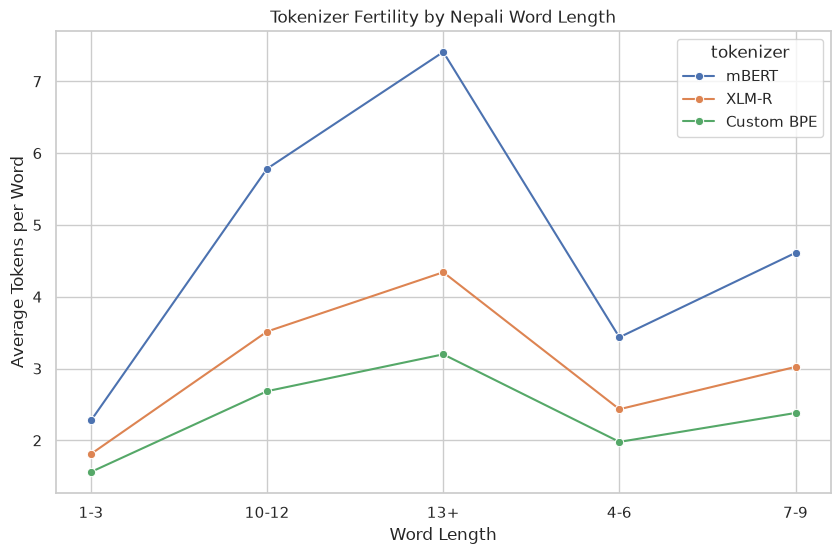

In [61]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=fertility_long,
    x="length_group",
    y="fertility",
    hue="tokenizer",
    marker="o"
)

plt.title(
    "Tokenizer Fertility by Nepali Word Length"
)

plt.xlabel(
    "Word Length"
)

plt.ylabel(
    "Average Tokens per Word"
)

plt.show()

## Overall Fertility

In [62]:
overall_fertility = pd.DataFrame({
    "Tokenizer": [
        "mBERT",
        "XLM-R",
        "Custom BPE"
    ],

    "Average Fertility": [
        words_df["mbert_fertility"].mean(),
        words_df["xlmr_fertility"].mean(),
        words_df["bpe_fertility"].mean()
    ]
})

display(
    overall_fertility
)

,Tokenizer,Average Fertility
0,mBERT,4.55480
1,XLM-R,2.96970
2,Custom BPE,2.33345


## Overall Fertility Plot

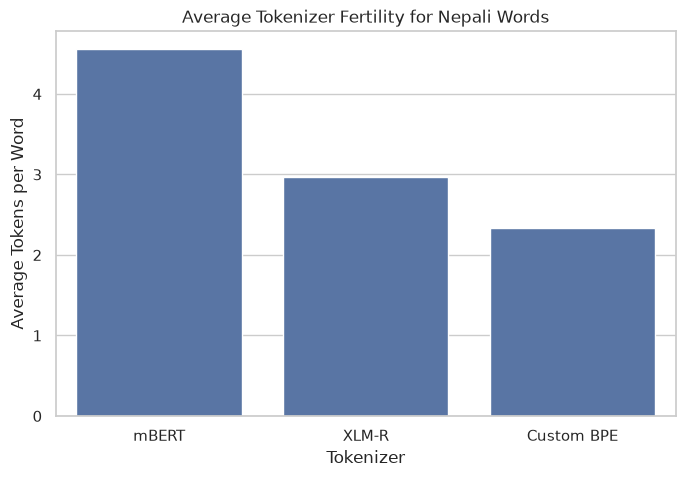

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=overall_fertility,
    x="Tokenizer",
    y="Average Fertility"
)

plt.title(
    "Average Tokenizer Fertility for Nepali Words"
)

plt.xlabel("Tokenizer")

plt.ylabel(
    "Average Tokens per Word"
)

plt.show()

## Fertility Distribution

In [64]:
distribution_df = words_df[
    [
        "mbert_fertility",
        "xlmr_fertility",
        "bpe_fertility"
    ]
].rename(
    columns={
        "mbert_fertility": "mBERT",
        "xlmr_fertility": "XLM-R",
        "bpe_fertility": "Custom BPE"
    }
)

distribution_long = distribution_df.melt(
    var_name="Tokenizer",
    value_name="Fertility"
)

## Plot

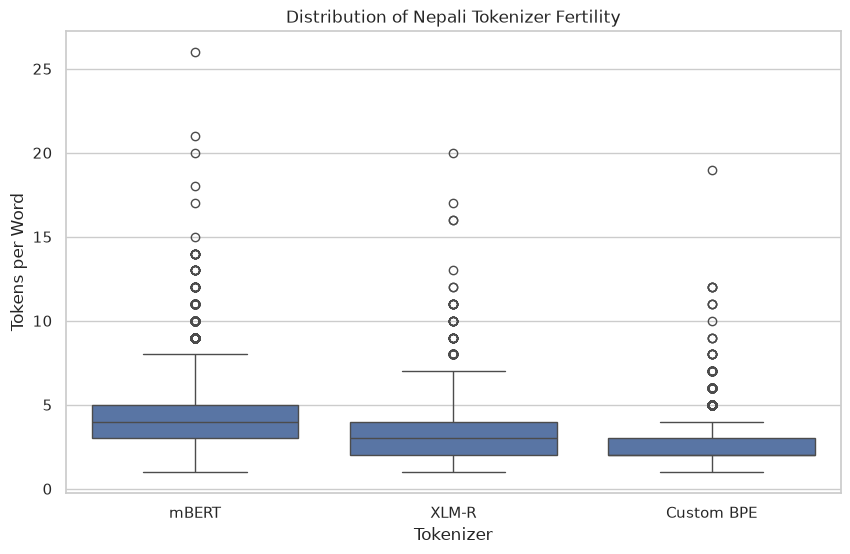

In [65]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=distribution_long,
    x="Tokenizer",
    y="Fertility"
)

plt.title(
    "Distribution of Nepali Tokenizer Fertility"
)

plt.xlabel("Tokenizer")

plt.ylabel(
    "Tokens per Word"
)

plt.show()

## Root vs. inflected words

In [66]:
root_words = [
    "घर",
    "किताब",
    "विद्यालय",
    "विद्यार्थी",
    "नेपाल",
    "मान्छे",
    "साथी",
    "देश",
    "समाज",
    "भाषा",
    "कथा",
    "काम",
    "पानी",
    "बाटो",
    "समय"
]

In [67]:
inflected_words = [
    "घरमा",
    "घरको",
    "घरलाई",
    "घरबाट",
    "किताबमा",
    "किताबको",
    "विद्यालयमा",
    "विद्यार्थीलाई",
    "नेपालमा",
    "नेपालको",
    "मान्छेहरू",
    "साथीलाई",
    "देशमा",
    "समाजको",
    "भाषामा"
]

## Creating Morphology Dataset

In [68]:
morphology_df = pd.DataFrame({
    "word": (
        root_words +
        inflected_words
    ),

    "form": (
        ["Root"] * len(root_words)
        +
        ["Inflected"] * len(inflected_words)
    )
})

display(
    morphology_df
)

,word,form
0,घर,Root
1,किताब,Root
2,विद्यालय,Root
3,विद्यार्थी,Root
4,नेपाल,Root
5,मान्छे,Root
6,साथी,Root
7,देश,Root
8,समाज,Root
9,भाषा,Root


## Tokenizing these words

In [69]:
morphology_df["mbert_tokens"] = (
    morphology_df["word"]
    .apply(mbert_token_count)
)

morphology_df["xlmr_tokens"] = (
    morphology_df["word"]
    .apply(xlmr_token_count)
)

morphology_df["bpe_tokens"] = (
    morphology_df["word"]
    .apply(bpe_token_count)
)

## Results

In [70]:
display(
    morphology_df
)

,word,form,mbert_tokens,xlmr_tokens,bpe_tokens
0,घर,Root,1,1,1
1,किताब,Root,3,1,1
2,विद्यालय,Root,2,1,1
3,विद्यार्थी,Root,5,1,1
4,नेपाल,Root,1,1,1
5,मान्छे,Root,3,1,1
6,साथी,Root,2,1,1
7,देश,Root,1,1,1
8,समाज,Root,1,1,1
9,भाषा,Root,1,1,1


## Root vs Inflected average

In [71]:
morphology_summary = (
    morphology_df
    .groupby("form")
    [
        [
            "mbert_tokens",
            "xlmr_tokens",
            "bpe_tokens"
        ]
    ]
    .mean()
    .reset_index()
)

display(
    morphology_summary
)

,form,mbert_tokens,xlmr_tokens,bpe_tokens
0,Inflected,2.733333,1.733333,1.333333
1,Root,1.800000,1.000000,1.000000


## Plotting root vs Inflected

In [72]:
morphology_long = (
    morphology_summary
    .melt(
        id_vars="form",
        var_name="Tokenizer",
        value_name="Fertility"
    )
)

morphology_long["Tokenizer"] = (
    morphology_long["Tokenizer"]
    .map({
        "mbert_tokens": "mBERT",
        "xlmr_tokens": "XLM-R",
        "bpe_tokens": "Custom BPE"
    })
)

## Plot

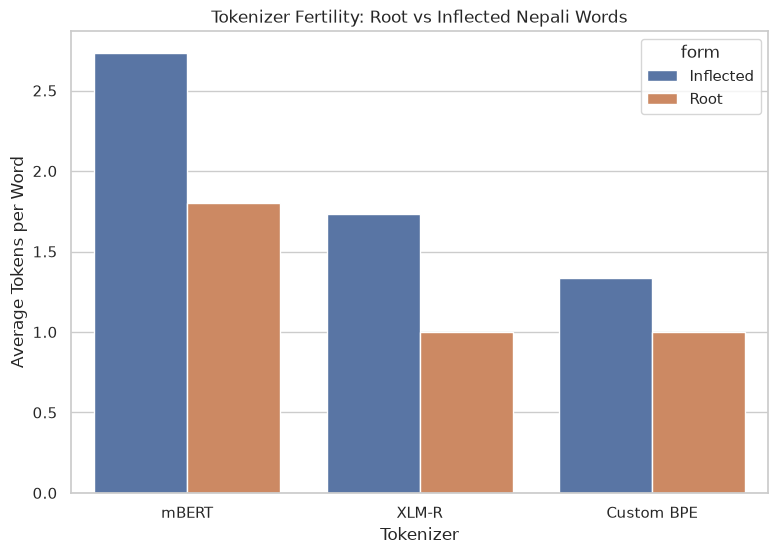

In [73]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=morphology_long,
    x="Tokenizer",
    y="Fertility",
    hue="form"
)

plt.title(
    "Tokenizer Fertility: Root vs Inflected Nepali Words"
)

plt.xlabel("Tokenizer")

plt.ylabel(
    "Average Tokens per Word"
)

plt.show()

## Actual Examples

In [74]:
examples = [
    "घर",
    "घरमा",
    "घरबाट",
    "घरको",
    "नेपाल",
    "नेपालमा",
    "विद्यार्थी",
    "विद्यार्थीलाई"
]

for word in examples:

    print("=" * 60)

    print(
        "WORD:",
        word
    )

    print(
        "mBERT:",
        mbert_tokenizer.tokenize(word)
    )

    print(
        "XLM-R:",
        xlmr_tokenizer.tokenize(word)
    )

    print(
        "Custom BPE:",
        custom_bpe.encode(word).tokens
    )

WORD: घर
mBERT: ['घर']
XLM-R: ['▁घर']
Custom BPE: ['घर']
WORD: घरमा
mBERT: ['घर', '##मा']
XLM-R: ['▁घरमा']
Custom BPE: ['घरमा']
WORD: घरबाट
mBERT: ['घर', '##बाट']
XLM-R: ['▁घर', 'बाट']
Custom BPE: ['घरबाट']
WORD: घरको
mBERT: ['घर', '##को']
XLM-R: ['▁घर', 'को']
Custom BPE: ['घरको']
WORD: नेपाल
mBERT: ['नेपाल']
XLM-R: ['▁नेपाल']
Custom BPE: ['नेपाल']
WORD: नेपालमा
mBERT: ['नेपाल', '##मा']
XLM-R: ['▁नेपालमा']
Custom BPE: ['नेपालमा']
WORD: विद्यार्थी
mBERT: ['वि', '##द्य', '##ार', '##्थ', '##ी']
XLM-R: ['▁विद्यार्थी']
Custom BPE: ['विद्यार्थी']
WORD: विद्यार्थीलाई
mBERT: ['वि', '##द्य', '##ार', '##्थ', '##ील', '##ाई']
XLM-R: ['▁विद्यार्थी', 'लाई']
Custom BPE: ['विद्यार्थीलाई']


## Overall Findings

In [75]:
display(overall_fertility)

display(fertility_by_length)

display(morphology_summary)

,Tokenizer,Average Fertility
0,mBERT,4.55480
1,XLM-R,2.96970
2,Custom BPE,2.33345


,length_group,mbert_fertility,xlmr_fertility,bpe_fertility
0,1-3,2.276334,1.809850,1.559508
1,10-12,5.783409,3.515604,2.684716
2,13+,7.408742,4.341258,3.197853
3,4-6,3.435187,2.433297,1.978422
4,7-9,4.611542,3.022880,2.381213


,form,mbert_tokens,xlmr_tokens,bpe_tokens
0,Inflected,2.733333,1.733333,1.333333
1,Root,1.800000,1.000000,1.000000


# Part 2 — Neural Network: Mixed-Script Detection

**Continues directly from the EDA and tokenizer-fertility analysis above.**

The EDA established that this corpus has no built-in supervised label (see "Target/Class Distribution" above). This section derives one from the noise audit already computed on `df` — the `has_latin` flag — and trains a neural network to predict it: **does a Nepali text record contain Latin-script content (mixed-script), or is it pure Devanagari?**

This reuses the same `df` already in memory (cleaned, with `has_latin` and `has_devanagari` computed in the Noise Audit section above) — no re-download or re-cleaning needed. If you are running this section on its own in a fresh kernel, run all cells above first.


## Installing additional packages for the neural network stage

In [76]:
!pip install -q torch scikit-learn


## Imports

In [77]:
import time
import copy
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    classification_report, accuracy_score, f1_score
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


## Label check

`has_latin` was already computed in the Noise Audit section above. We only need to rename it as the classification target and confirm the class balance.

In [78]:
nn_df = df.copy()
nn_df["label"] = nn_df["has_latin"].astype(int)  # 1 = mixed-script, 0 = pure Devanagari

print("Total records:", len(nn_df))
print(f"Mixed-script rate: {nn_df['label'].mean():.4%}")
nn_df[["clean_text", "has_latin", "has_devanagari", "label"]].head()


Total records: 99994
Mixed-script rate: 4.3823%


,clean_text,has_latin,has_devanagari,label
0,राष्ट्रपति विद्यादेवी भण्डारी आफूले संसद्को अध...,False,True,0
1,बुधबार अपरान्ह ४ बजे तिर नदिमा नुहाउने क्रममा ...,False,True,0
2,चलचित्रका लेखक अभिषेक सुवेदीले चलचित्रलाई प्रा...,False,True,0
3,4 (Nepali) आज मेरो उम्मेदवार जेरोम पावेल अर्को...,True,True,1
4,"काठमाडौँ, भदौ ६ गते । नेपाल बन्दको विरोध गर्दै...",False,True,0


## Stratified train / validation / test split

Unlike the EDA-stage split above (plain random, since there was no target yet), this stage stratifies on `label` so the minority mixed-script class is represented proportionally in every split.

In [79]:
nn_train_df, nn_temp_df = train_test_split(
    nn_df, test_size=0.20, random_state=RANDOM_SEED, stratify=nn_df["label"]
)
nn_val_df, nn_test_df = train_test_split(
    nn_temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=nn_temp_df["label"]
)

nn_train_df = nn_train_df.reset_index(drop=True)
nn_val_df = nn_val_df.reset_index(drop=True)
nn_test_df = nn_test_df.reset_index(drop=True)

print("train:", len(nn_train_df), " val:", len(nn_val_df), " test:", len(nn_test_df))
print("Mixed-script rate — train:", nn_train_df["label"].mean(),
      " val:", nn_val_df["label"].mean(), " test:", nn_test_df["label"].mean())


train: 79995  val: 9999  test: 10000
Mixed-script rate — train: 0.043827739233702104  val: 0.043804380438043806  test: 0.0438


## Vocabulary

A simple whitespace-level vocabulary built only from the training split (standard practice — the validation/test sets must stay unseen).

In [80]:
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"
MAX_VOCAB_SIZE = 20_000
MIN_FREQ = 2
MAX_LEN = 64

class WhitespaceVocab:
    def __init__(self, max_vocab_size=20_000, min_freq=2):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.token2id = {PAD_TOKEN: 0, UNK_TOKEN: 1}

    def build(self, texts):
        counter = Counter()
        for t in texts:
            counter.update(t.split())
        most_common = [
            (tok, freq) for tok, freq in counter.most_common()
            if freq >= self.min_freq
        ][: self.max_vocab_size - len(self.token2id)]
        for tok, _ in most_common:
            self.token2id[tok] = len(self.token2id)
        return self

    def __len__(self):
        return len(self.token2id)

    def encode(self, text, max_len):
        ids = [self.token2id.get(tok, self.token2id[UNK_TOKEN]) for tok in text.split()]
        ids = ids[:max_len]
        ids = ids + [self.token2id[PAD_TOKEN]] * (max_len - len(ids))
        return ids

vocab = WhitespaceVocab(max_vocab_size=MAX_VOCAB_SIZE, min_freq=MIN_FREQ)
vocab.build(nn_train_df["clean_text"])
print("Vocabulary size:", len(vocab))


Vocabulary size: 20000


## PyTorch Dataset

In [81]:
class MixedScriptDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        x = torch.tensor(ids, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

train_ds = MixedScriptDataset(nn_train_df["clean_text"], nn_train_df["label"], vocab, MAX_LEN)
val_ds   = MixedScriptDataset(nn_val_df["clean_text"],   nn_val_df["label"],   vocab, MAX_LEN)
test_ds  = MixedScriptDataset(nn_test_df["clean_text"],  nn_test_df["label"],  vocab, MAX_LEN)


## Model architectures

**TextCNN** — embedding → parallel 1D convolutions (kernel widths 3/4/5) → global max-pool each → concat → dropout → linear logit. Good at catching a short Latin word/acronym anywhere in the sentence.

**TextBiLSTM** — embedding → bidirectional LSTM → concat final forward/backward hidden states → dropout → linear logit. Uses the full sequence context rather than local windows.

In [82]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=64,
                 kernel_sizes=(3, 4, 5), dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)        # [B, E, L]
        pooled = [torch.max(torch.relu(conv(emb)), dim=2).values for conv in self.convs]
        feat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(feat).squeeze(1)


class TextBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64,
                 dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        feat = self.dropout(torch.cat([h_n[0], h_n[1]], dim=1))
        return self.fc(feat).squeeze(1)


def build_model(name, vocab_size, **kwargs):
    if name == "cnn":
        return TextCNN(vocab_size, **kwargs)
    elif name == "bilstm":
        return TextBiLSTM(vocab_size, **kwargs)
    raise ValueError(f"Unknown model name: {name}")


## Training loop, class-imbalance handling, and hyperparameter sweep

The mixed-script class is a small minority (~4% in the full corpus), so plain BCE loss would let the model mostly ignore it and still score well on accuracy. This is corrected with a `pos_weight` on `BCEWithLogitsLoss`, computed from the training set's actual class ratio — and macro-F1 (not accuracy) is used to pick the best configuration.

In [83]:
def compute_pos_weight(labels):
    labels = list(labels)
    n_pos = sum(labels)
    n_neg = len(labels) - n_pos
    return torch.tensor(n_neg / n_pos if n_pos else 1.0, dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, n_batches = 0.0, 0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_train:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        n_batches += 1
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.long().cpu().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return total_loss / max(n_batches, 1), macro_f1


def train_one_config(config, train_ds, val_ds, vocab_size, device="cpu", verbose=True):
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False)

    model_kwargs = {k: v for k, v in config.items()
                     if k in ("embed_dim", "num_filters", "kernel_sizes", "hidden_dim", "dropout")}
    model = build_model(config["model_name"], vocab_size, **model_kwargs).to(device)

    pos_weight = compute_pos_weight(train_ds.labels).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1, best_state = -1.0, None

    for epoch in range(config["epochs"]):
        t0 = time.time()
        train_loss, train_f1 = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1 = run_epoch(model, val_loader, criterion, None, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
        if verbose:
            print(f"  epoch {epoch+1}/{config['epochs']} "
                  f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"train_f1={train_f1:.4f} val_f1={val_f1:.4f} ({time.time()-t0:.1f}s)")

    model.load_state_dict(best_state)
    return model, history, best_val_f1


def hyperparameter_sweep(configs, train_ds, val_ds, vocab_size, device="cpu"):
    results, best = [], None
    for i, config in enumerate(configs):
        print(f"\n=== Config {i+1}/{len(configs)}: {config} ===")
        model, history, val_f1 = train_one_config(config, train_ds, val_ds, vocab_size, device)
        results.append({"config": config, "val_f1": val_f1, "history": history})
        if best is None or val_f1 > best["val_f1"]:
            best = {"config": config, "model": model, "history": history, "val_f1": val_f1}
    print("\n=== Hyperparameter sweep summary ===")
    for r in results:
        print(f"val_macro_f1={r['val_f1']:.4f}  config={r['config']}")
    print(f"\nBest config: {best['config']}  (val_macro_f1={best['val_f1']:.4f})")
    return best["config"], best["model"], best["history"], results


## Running the sweep

Set `MODEL_NAME = "bilstm"` to compare the RNN architecture instead. Each config varies embedding size, filters/hidden size, dropout, learning rate, and batch size — this is the "adjust the hyperparameters and observe the output" step.

In [84]:
print("train_ds:", "train_ds" in globals())
print("val_ds:", "val_ds" in globals())
print("vocab:", "vocab" in globals())
print("DEVICE:", "DEVICE" in globals())
print("hyperparameter_sweep:", "hyperparameter_sweep" in globals())

train_ds: True
val_ds: True
vocab: True
DEVICE: True
hyperparameter_sweep: True


In [85]:
MODEL_NAME = "cnn"  # or "bilstm"

if MODEL_NAME == "cnn":
    configs = [
        {"model_name": "cnn", "embed_dim": 64,  "num_filters": 32, "kernel_sizes": (3,4,5), "dropout": 0.3, "lr": 1e-3, "batch_size": 64,  "epochs": 6},
        {"model_name": "cnn", "embed_dim": 128, "num_filters": 64, "kernel_sizes": (3,4,5), "dropout": 0.3, "lr": 1e-3, "batch_size": 64,  "epochs": 6},
        {"model_name": "cnn", "embed_dim": 128, "num_filters": 64, "kernel_sizes": (3,4,5), "dropout": 0.5, "lr": 5e-4, "batch_size": 128, "epochs": 6},
    ]
else:
    configs = [
        {"model_name": "bilstm", "embed_dim": 64,  "hidden_dim": 32, "dropout": 0.3, "lr": 1e-3, "batch_size": 64,  "epochs": 6},
        {"model_name": "bilstm", "embed_dim": 128, "hidden_dim": 64, "dropout": 0.3, "lr": 1e-3, "batch_size": 64,  "epochs": 6},
        {"model_name": "bilstm", "embed_dim": 128, "hidden_dim": 64, "dropout": 0.5, "lr": 5e-4, "batch_size": 128, "epochs": 6},
    ]

best_config, best_model, best_history, all_results = hyperparameter_sweep(
    configs, train_ds, val_ds, len(vocab), device=DEVICE
)



=== Config 1/3: {'model_name': 'cnn', 'embed_dim': 64, 'num_filters': 32, 'kernel_sizes': (3, 4, 5), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'epochs': 6} ===
  epoch 1/6 train_loss=1.0516 val_loss=0.8422 train_f1=0.5179 val_f1=0.6463 (4.2s)
  epoch 2/6 train_loss=0.7740 val_loss=0.7884 train_f1=0.6053 val_f1=0.6711 (3.5s)
  epoch 3/6 train_loss=0.5468 val_loss=0.8244 train_f1=0.6727 val_f1=0.6709 (2.9s)
  epoch 4/6 train_loss=0.3655 val_loss=0.9079 train_f1=0.7397 val_f1=0.6389 (3.4s)
  epoch 5/6 train_loss=0.2471 val_loss=1.4282 train_f1=0.7944 val_f1=0.7284 (3.5s)
  epoch 6/6 train_loss=0.1754 val_loss=1.6312 train_f1=0.8395 val_f1=0.7390 (3.4s)

=== Config 2/3: {'model_name': 'cnn', 'embed_dim': 128, 'num_filters': 64, 'kernel_sizes': (3, 4, 5), 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'epochs': 6} ===
  epoch 1/6 train_loss=1.0109 val_loss=0.8248 train_f1=0.5317 val_f1=0.6804 (3.2s)
  epoch 2/6 train_loss=0.6914 val_loss=0.8102 train_f1=0.6302 val_f1=0.5435 (3.3s)
  e

## Training curves for the best configuration

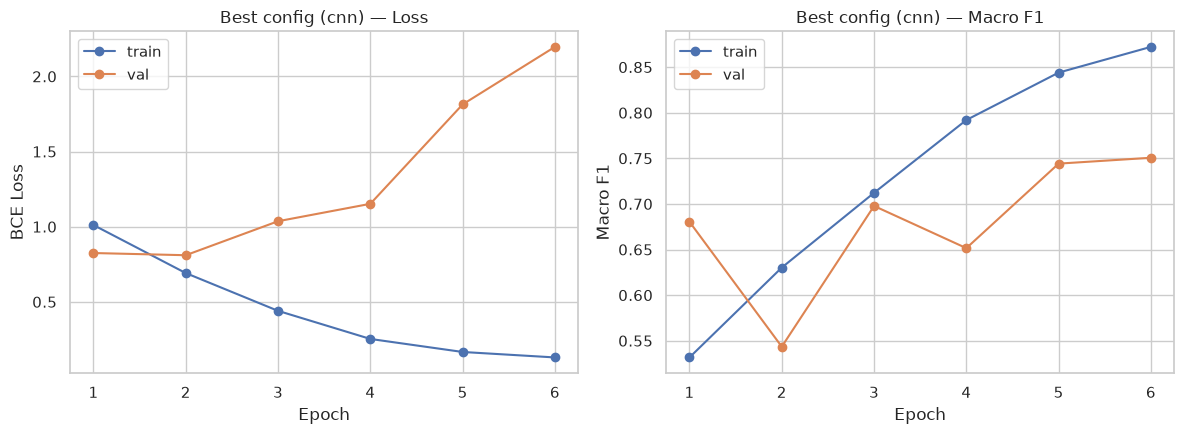

In [86]:
epochs_range = range(1, len(best_history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, best_history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, best_history["val_loss"], marker="o", label="val")
axes[0].set_title(f"Best config ({MODEL_NAME}) — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(epochs_range, best_history["train_f1"], marker="o", label="train")
axes[1].plot(epochs_range, best_history["val_f1"], marker="o", label="val")
axes[1].set_title(f"Best config ({MODEL_NAME}) — Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()

plt.tight_layout()
plt.show()


## Final evaluation on the held-out test set

Accuracy, per-class precision/recall/F1, macro-averaged precision/recall/F1, and the confusion matrix — on data never used for training or hyperparameter selection.

In [87]:
LABEL_NAMES = ["Pure Devanagari", "Mixed-script"]

def get_predictions(model, dataset, device="cpu", batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(y.long().tolist())
    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(best_model, test_ds, device=DEVICE)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1], zero_division=0
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {macro_p:.4f}  Macro Recall: {macro_r:.4f}  Macro F1: {macro_f1:.4f}")
print("\nPer-class report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=LABEL_NAMES, zero_division=0))
print("Confusion matrix (rows=true, cols=predicted):")
print(cm)


Accuracy: 0.9515
Macro Precision: 0.7240  Macro Recall: 0.8200  Macro F1: 0.7620

Per-class report:
                 precision    recall  f1-score   support

Pure Devanagari       0.98      0.96      0.97      9562
   Mixed-script       0.46      0.68      0.55       438

       accuracy                           0.95     10000
      macro avg       0.72      0.82      0.76     10000
   weighted avg       0.96      0.95      0.96     10000

Confusion matrix (rows=true, cols=predicted):
[[9219  343]
 [ 142  296]]


## Confusion matrix plot

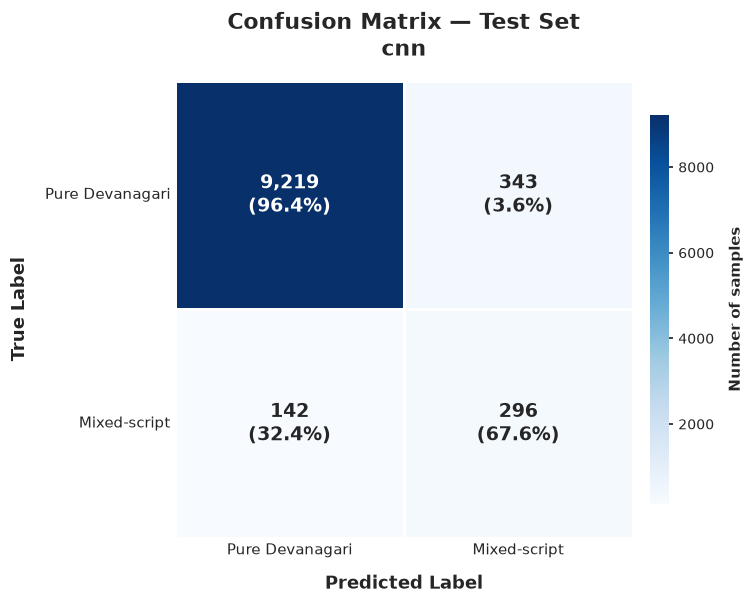

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# Confusion Matrix - Publication Quality
# ---------------------------------------------------------

# Optional: make labels cleaner
display_labels = [
    "Pure Devanagari",
    "Mixed-script"
]

# Calculate percentages row-wise
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

# Create annotation: count + percentage
annotations = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f"{cm[i, j]:,}\n({cm_percent[i, j]:.1f}%)"


# Create figure
fig, ax = plt.subplots(figsize=(8, 6.5))

# Heatmap
sns.heatmap(
    cm,
    annot=annotations,
    fmt="",
    cmap="Blues",

    # Make cells clean and separated
    linewidths=2,
    linecolor="white",

    # Labels
    xticklabels=display_labels,
    yticklabels=display_labels,

    # Colorbar
    cbar=True,
    cbar_kws={
        "label": "Number of samples",
        "shrink": 0.85,
        "pad": 0.03
    },

    # Annotation style
    annot_kws={
        "fontsize": 14,
        "fontweight": "bold"
    },

    ax=ax
)


ax.set_xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight="bold",
    labelpad=12
)

ax.set_ylabel(
    "True Label",
    fontsize=13,
    fontweight="bold",
    labelpad=12
)

# Title
ax.set_title(
    f"Confusion Matrix — Test Set\n{MODEL_NAME}",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    length=0
)

# Keep labels horizontal
plt.setp(
    ax.get_xticklabels(),
    rotation=0,
    ha="center"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0,
    va="center"
)

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=10,
    length=3
)

cbar.set_label(
    "Number of samples",
    fontsize=11,
    fontweight="bold",
    labelpad=10
)

for spine in ax.spines.values():
    spine.set_visible(False)

# Make cells square
ax.set_aspect("equal")

# Adjust layout
plt.tight_layout(pad=2)

plt.show()


## Discussion notes

- How does macro-F1 compare to plain accuracy here, and why (see the class-imbalance handling above)?
- Which hyperparameter configuration won — is that stable across more than one run/seed?
- Inspect a few misclassified examples (false positives/negatives) — do they reveal a pattern (e.g. short numeric/alphanumeric codes, rare Latin brand names, romanized Nepali)?
- How would this compare to a trivial regex baseline (`re.search(r"[A-Za-z]", text)`)? What does the neural network add over that baseline, if anything — a fair point to raise as a limitation.


## Inspecting misclassified examples

In [89]:
nn_test_df_reset = nn_test_df.reset_index(drop=True)
mistakes = nn_test_df_reset[(y_true != y_pred)].copy()
mistakes["true_label"] = y_true[(y_true != y_pred)]
mistakes["pred_label"] = y_pred[(y_true != y_pred)]

print(f"Misclassified: {len(mistakes)} / {len(nn_test_df_reset)}")
display(mistakes[["clean_text", "true_label", "pred_label"]].head(10))


Misclassified: 485 / 10000


,clean_text,true_label,pred_label
45,"२६ फागुन, कञ्चनपुर । कञ्चनपुरस्थित आनन्दबजारमा...",0,1
48,भुकम्प प्रभावित जिल्लाहरुमा पशुपन्छी सम्बन्धी ...,1,0
52,कोरिया को प्रवासी मजदुर संगठन (एमटियु) को तर्फ...,0,1
101,आधारभूत मार्गदर्शन २०७२ स्वीकृत हुनुभन्दा २०७२...,0,1
116,"ARCHIVE, CORPORATE » सिटिजन्स बैंक र नर्भिक हस...",1,0
125,जहाँ तिनीहरूले FS9 मा स्थापना म सम्झना छैन। पन...,1,0
135,"२०४९/०५० मा बुटवलमा पत्रकारहरु बसन्तध्वज जोशी,...",0,1
142,अहिले शेष घलेको पालोबाट यो देश दोहनको क्रम रोक...,1,0
160,प्रचन्ड को यो भुमिगत जिवनको बिसाइ र खुला जिवनक...,0,1
184,२०७५ जेठ ३ गते नेकपा (एमाले) र नेकपा (माओवादी ...,0,1


## Overall Findings — Part 2

Run the cells above, then summarize here: which model/config won, the final macro-F1 / precision / recall, and what the confusion matrix and misclassified examples suggest about mixed-script detection in Nepali web text.